In [9]:
import pandas as pd
import numpy as np
 
np.random.seed(42)
countries = [
    ('Mexico','MEX'),('USA','USA'),('Germany','DEU'),('China','CHN'),
    ('Brazil','BRA'),('India','IND'),('France','FRA'),('Japan','JPN'),
    # ... agregar hasta 150 paises
]
years = range(2000, 2024)
records = []
for country, iso in countries:
    for year in years:
        records.append({
            'Country': country, 'ISO_Code': iso, 'Year': year,
            'CO2_Emissions_Per_Capita': np.random.uniform(0.5, 18.0),
            'Average_Credit_Score_Corporate': np.random.uniform(300, 850),
            'GDP_Per_Capita': np.random.uniform(500, 65000),
            'Trade_Connectivity_Index': np.random.uniform(10, 95),
        })
df = pd.DataFrame(records)
df.to_csv('global_esg_risk.csv', index=False)
print(f'Dataset generado: {len(df)} filas x {len(df.columns)} columnas')


Dataset generado: 192 filas x 7 columnas


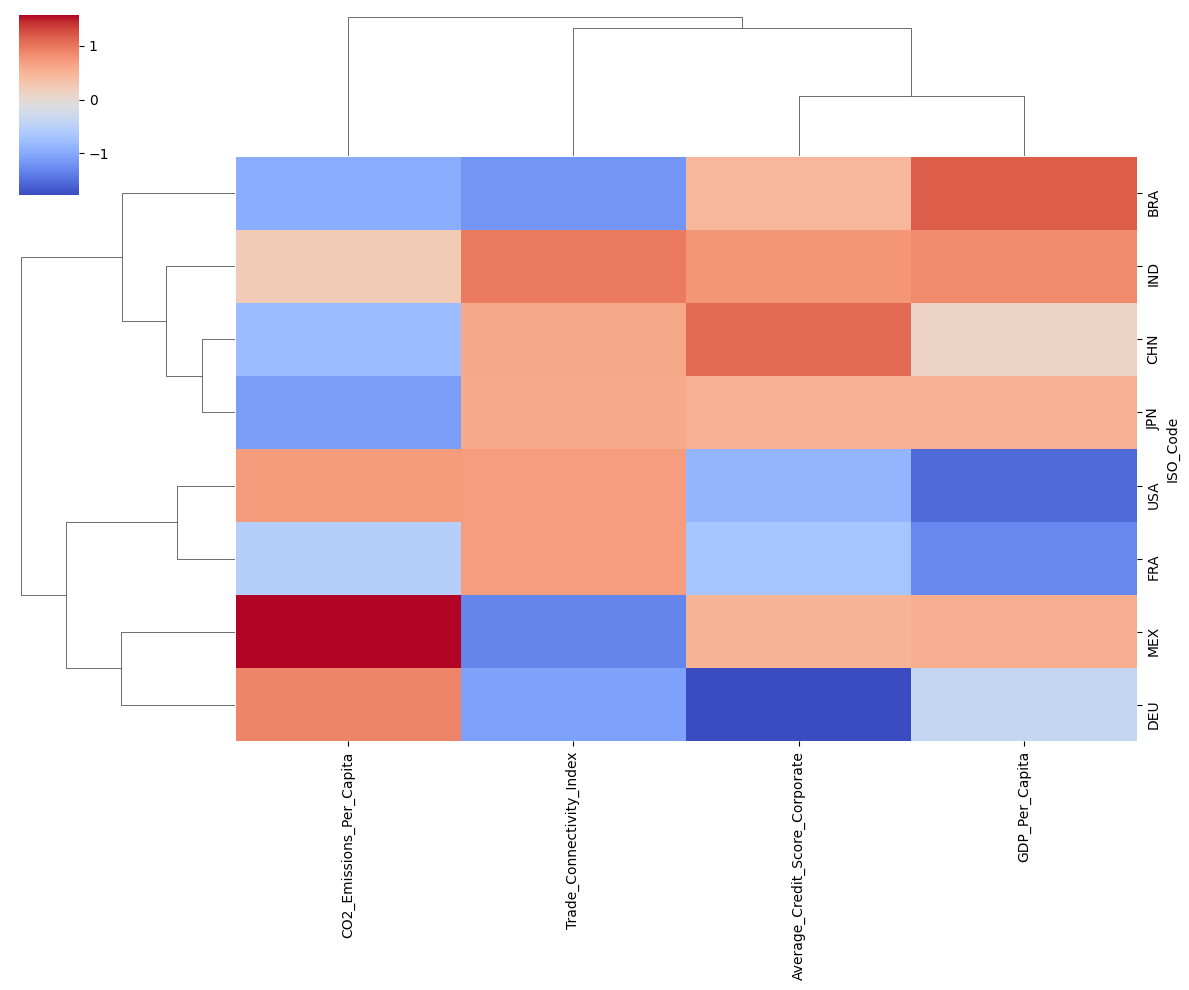

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar 2023
df_2023 = df[df['Year'] == 2023].copy()

# Seleccionar columnas
cluster_data = df_2023[
    [
        'ISO_Code',
        'CO2_Emissions_Per_Capita',
        'Average_Credit_Score_Corporate',
        'GDP_Per_Capita',
        'Trade_Connectivity_Index'
    ]
]

cluster_data = cluster_data.set_index('ISO_Code')

# Clustermap
cluster = sns.clustermap(
    cluster_data,
    z_score=1,
    method='ward',
    cmap='coolwarm',
    figsize=(12, 10)
)

# Exportar
plt.savefig('clustermap_2023.png', dpi=300, bbox_inches='tight')

plt.show()

Index(['Country', 'ISO_Code', 'Year', 'CO2_Emissions_Per_Capita',
       'Average_Credit_Score_Corporate', 'GDP_Per_Capita',
       'Trade_Connectivity_Index'],
      dtype='str')


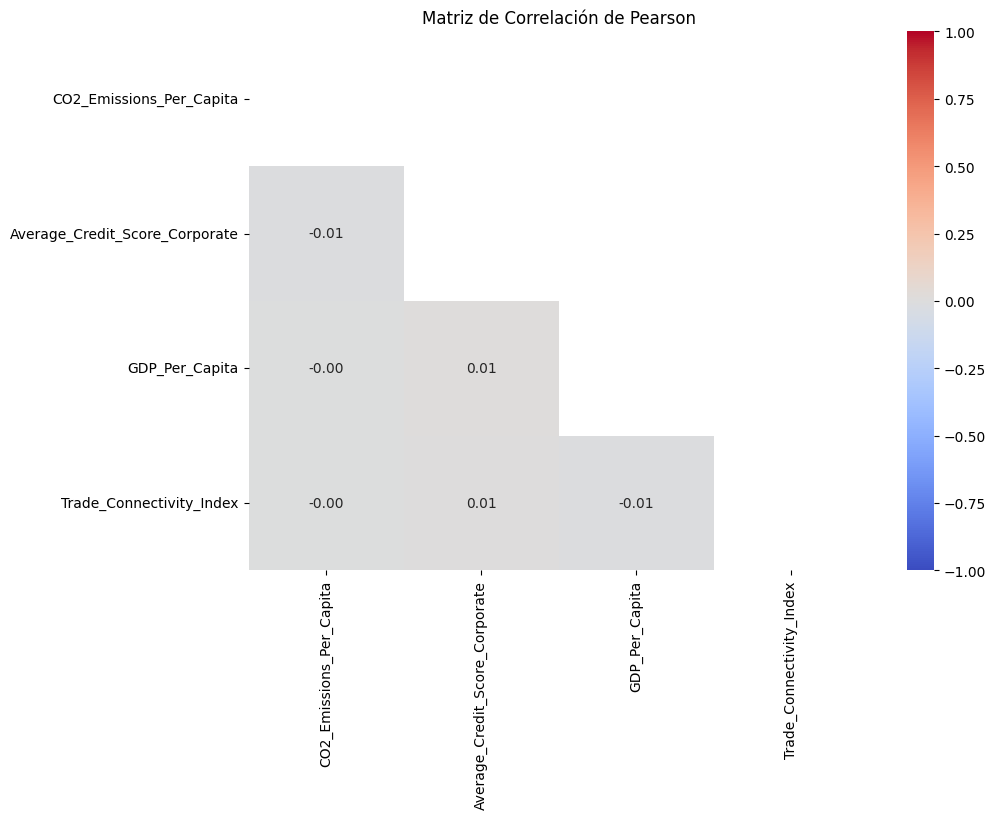

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Cargar dataset
df = pd.read_csv('global_esg_risk.csv')

# Verificar columnas
print(df.columns)

# Columnas numéricas
numeric_cols = [
    'CO2_Emissions_Per_Capita',
    'Average_Credit_Score_Corporate',
    'GDP_Per_Capita',
    'Trade_Connectivity_Index'
]

# Matriz de correlación
corr_matrix = df[numeric_cols].corr()

# Máscara triangular
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Tamaño de figura
plt.figure(figsize=(10, 7))

# Heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

# Título
plt.title('Matriz de Correlación de Pearson')

# Guardar imagen
plt.savefig(
    'heatmap_correlacion.png',
    dpi=300,
    bbox_inches='tight'
)

# Mostrar gráfico
plt.show()

In [26]:
import pandas as pd
import plotly.express as px
import numpy as np
import plotly.io as pio

# Configurar renderizador
pio.renderers.default = 'browser'

# Cargar datos
df = pd.read_csv('global_esg_risk.csv')

# Top 15 países
top15 = (
    df.groupby('Country')
    ['Trade_Connectivity_Index']
    .mean()
    .nlargest(15)
    .index
    .tolist()
)

# Matriz aleatoria
np.random.seed(42)

adj_matrix = np.random.randint(
    10,
    100,
    size=(len(top15), len(top15))
)

# Figura
fig = px.imshow(
    adj_matrix,
    x=top15,
    y=top15,
    color_continuous_scale='Viridis'
)

# Tooltip
fig.update_traces(
    hovertemplate=
    'Origen: %{y}<br>' +
    'Destino: %{x}<br>' +
    'Volumen: %{z}<extra></extra>'
)

# Título
fig.update_layout(
    title='Matriz de Adyacencia Comercial'
)

# Guardar HTML
fig.write_html(
    'matriz_adyacencia.html'
)

# Mostrar
fig.show()

In [2]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# Solución para VS Code / Jupyter
pio.renderers.default = 'browser'

# Cargar datos
df = pd.read_csv('global_esg_risk.csv')

# Eliminar valores nulos
df_clean = df.dropna(
    subset=[
        'ISO_Code',
        'CO2_Emissions_Per_Capita'
    ]
)

# Crear mapa
fig = px.choropleth(
    df_clean,
    locations='ISO_Code',
    locationmode='ISO-3',
    color='CO2_Emissions_Per_Capita',
    animation_frame='Year',
    color_continuous_scale='YlOrRd',
    projection='natural earth',
    title='Evolución Global de Emisiones CO2'
)

# Guardar HTML
fig.write_html(
    'choropleth_co2.html'
)

# Mostrar gráfico
fig.show()


In [13]:
import streamlit as st
import pandas as pd
import plotly.express as px

# Configuración
st.set_page_config(
    layout='wide',
    page_title='Atlas ESG Dashboard'
)

# Cargar datos
@st.cache_data
def load_data():

    return pd.read_csv(
        'global_esg_risk.csv'
    )

df = load_data()

# Sidebar
st.sidebar.title(
    'Filtros de Inversión'
)

# Slider de años
year_range = st.sidebar.slider(
    'Rango de años',
    2000,
    2023,
    (2000,2023)
)

# Nivel de riesgo
risk_level = st.sidebar.selectbox(
    'Nivel de Riesgo',
    [
        'Todos',
        'Alto (>700)',
        'Medio (500-700)',
        'Bajo (<500)'
    ]
)

# Filtrado
df_filtered = df[
    (df['Year'] >= year_range[0]) &
    (df['Year'] <= year_range[1])
]

# Riesgo alto
if risk_level == 'Alto (>700)':

    df_filtered = df_filtered[
        df_filtered[
            'Average_Credit_Score_Corporate'
        ] > 700
    ]

# Riesgo medio
elif risk_level == 'Medio (500-700)':

    df_filtered = df_filtered[
        (
            df_filtered[
                'Average_Credit_Score_Corporate'
            ] >= 500
        )
        &
        (
            df_filtered[
                'Average_Credit_Score_Corporate'
            ] <= 700
        )
    ]

# Riesgo bajo
elif risk_level == 'Bajo (<500)':

    df_filtered = df_filtered[
        df_filtered[
            'Average_Credit_Score_Corporate'
        ] < 500
    ]

# Título
st.title(
    'Atlas Global Capital | ESG Dashboard'
)

# Choropleth
fig = px.choropleth(
    df_filtered,
    locations='ISO_Code',
    locationmode='ISO-3',
    color='CO2_Emissions_Per_Capita',
    animation_frame='Year'
)

# Mostrar gráfico
st.plotly_chart(
    fig,
    use_container_width=True
)

2026-05-26 18:32:40.998 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 18:32:41.006 No runtime found, using MemoryCacheStorageManager


2026-05-26 18:32:41.037 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 18:32:41.039 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 18:32:41.042 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 18:32:41.045 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 18:32:41.048 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 18:32:41.049 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 18:32:41.053 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 18:32:41.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()